In [1]:
import polars as pl
import matplotlib.pyplot as plt

In [ ]:
df = pl.read_parquet("../data/modeling/base_modelado.parquet")

In [3]:
df.head()

id_sensor,id_fecha,hora,intensidad_media,intensidad_max,intensidad_min,ocupacion_media,ocupacion_max,velocidad_media,velocidad_min,num_mediciones,num_error_E,porcentaje_calidad,año,mes,nombre_mes,trimestre,dia,dia_semana,fin_semana,tipo_elem,distrito,latitud,longitud
i32,date,i32,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,i64,i64,str,i64,i64,i64,bool,str,i32,f64,f64
1001,2026-04-18,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,0.0,100.0,2026,4,"""April""",2,18,6,true,"""other""",10,40.409729,-3.740786
1001,2026-04-21,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,0.0,100.0,2026,4,"""April""",2,21,2,false,"""other""",10,40.409729,-3.740786
1001,2026-04-21,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,0.0,100.0,2026,4,"""April""",2,21,2,false,"""other""",10,40.409729,-3.740786
1002,2026-04-16,10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,0.0,100.0,2026,4,"""April""",2,16,4,false,"""other""",10,40.40803,-3.74376
1002,2026-04-17,21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,0.0,100.0,2026,4,"""April""",2,17,5,false,"""other""",10,40.40803,-3.74376


In [4]:
print(f"Filas: {df.height}")
print(f"Columnas: {df.width}")

Filas: 40521392
Columnas: 24


In [5]:
df.schema

Schema([('id_sensor', Int32),
        ('id_fecha', Date),
        ('hora', Int32),
        ('intensidad_media', Float64),
        ('intensidad_max', Float64),
        ('intensidad_min', Float64),
        ('ocupacion_media', Float64),
        ('ocupacion_max', Float64),
        ('velocidad_media', Float64),
        ('velocidad_min', Float64),
        ('num_mediciones', Int64),
        ('num_error_E', Float64),
        ('porcentaje_calidad', Float64),
        ('año', Int64),
        ('mes', Int64),
        ('nombre_mes', String),
        ('trimestre', Int64),
        ('dia', Int64),
        ('dia_semana', Int64),
        ('fin_semana', Boolean),
        ('tipo_elem', String),
        ('distrito', Int32),
        ('latitud', Float64),
        ('longitud', Float64)])

In [6]:
(
    df.null_count()
      .transpose(
          include_header=True,
          header_name="columna",
          column_names=["nulos"]
      )
      .sort("nulos", descending=True)
)

columna,nulos
str,u32
"""id_sensor""",0
"""id_fecha""",0
"""hora""",0
"""intensidad_media""",0
"""intensidad_max""",0
…,…
"""fin_semana""",0
"""tipo_elem""",0
"""distrito""",0


In [7]:
total_registros = df.height

registros_unicos = (
    df.select(
        [
            "id_sensor",
            "id_fecha",
            "hora"
        ]
    )
    .unique()
    .height
)

print(f"Registros totales: {total_registros}")
print(f"Registros únicos: {registros_unicos}")
print(
    f"Duplicados: {total_registros - registros_unicos}"
)

Registros totales: 40521392
Registros únicos: 40521392
Duplicados: 0


In [8]:
tipo = (
    df.group_by("tipo_elem")
      .agg(pl.len().alias("registros"))
      .sort("registros", descending=True)
)

tipo

tipo_elem,registros
str,u32
"""URB""",36939419
"""M30""",2595362
"""other""",986611


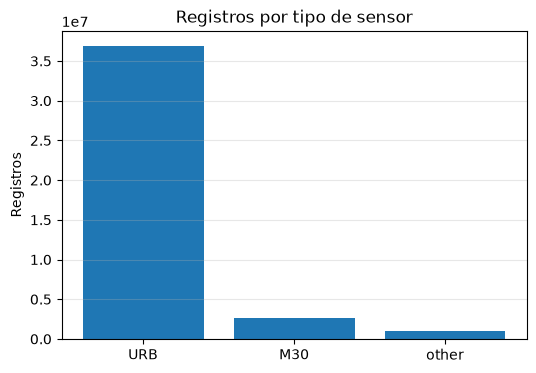

In [9]:
tipo_pd = tipo.to_pandas()

plt.figure(figsize=(6,4))

plt.bar(
    tipo_pd["tipo_elem"],
    tipo_pd["registros"]
)

plt.title("Registros por tipo de sensor")
plt.ylabel("Registros")

plt.grid(axis="y",alpha=.3)

plt.show()

La mayor parte de los registros corresponden a sensores URB (más de 36,9 millones), seguidos por M30 (2,6 millones) y other (casi 1 millón). Esta diferencia justifica analizar cada tipo de sensor por separado, ya que representan infraestructuras con características y comportamientos distintos.

In [14]:
def eda_tipo(df, tipo):

    print("="*60)
    print(f"ANÁLISIS {tipo}")
    print("="*60)

    datos = df.filter(
        pl.col("tipo_elem")==tipo
    )

    print(f"Registros: {datos.height:,}")
    print(f"Sensores: {datos['id_sensor'].n_unique()}")

    display(
        datos.select([
            "intensidad_media",
            "ocupacion_media",
            "velocidad_media"
        ]).describe()
    )

    muestra = datos.sample(
        n=min(100000, datos.height),
        seed=42
    )

    # ------------------------
    # Intensidad
    # ------------------------

    intensidad = muestra.filter(
        pl.col("intensidad_media") < 3000
    )["intensidad_media"].to_pandas()

    plt.figure(figsize=(8,4))

    intensidad.hist(
        bins=50,
        color="#4E79A7",
        edgecolor="white"
    )

    plt.title(f"Distribución de intensidad media ({tipo})")

    plt.xlabel("Vehículos")

    plt.ylabel("Frecuencia")

    plt.grid(alpha=.3)

    plt.tight_layout()

    plt.show()


    plt.figure(figsize=(8,2.5))

    plt.boxplot(
        intensidad,
        orientation="horizontal",
        patch_artist=True,
        boxprops=dict(facecolor="#4E79A7")
    )

    plt.title(f"Boxplot intensidad media ({tipo})")

    plt.tight_layout()

    plt.show()

    # ------------------------
    # Ocupación
    # ------------------------

    ocupacion = muestra["ocupacion_media"].to_pandas()

    plt.figure(figsize=(8,4))

    ocupacion.hist(
        bins=40,
        color="#59A14F",
        edgecolor="white"
    )

    plt.title(f"Distribución de ocupación media ({tipo})")

    plt.xlabel("%")

    plt.ylabel("Frecuencia")

    plt.grid(alpha=.3)

    plt.tight_layout()

    plt.show()


    plt.figure(figsize=(8,2.5))

    plt.boxplot(
        ocupacion,
        orientation="horizontal",
        patch_artist=True,
        boxprops=dict(facecolor="#59A14F")
    )

    plt.title(f"Boxplot ocupación media ({tipo})")

    plt.tight_layout()

    plt.show()


    # ------------------------
    # Velocidad
    # ------------------------

    if muestra["velocidad_media"].max() > 0:

        velocidad = muestra["velocidad_media"].to_pandas()

        plt.figure(figsize=(8,4))

        velocidad.hist(
            bins=40,
            color="#F28E2B",
            edgecolor="white"
        )

        plt.title(f"Distribución de velocidad media ({tipo})")

        plt.xlabel("km/h")

        plt.ylabel("Frecuencia")

        plt.grid(alpha=.3)

        plt.tight_layout()

        plt.show()


        plt.figure(figsize=(8,2.5))

        plt.boxplot(
            velocidad,
            orientation="horizontal",
            patch_artist=True,
            boxprops=dict(facecolor="#F28E2B")
        )

        plt.title(f"Boxplot velocidad media ({tipo})")

        plt.tight_layout()

        plt.show()

    else:

        print("Este tipo de sensor no registra velocidad.")

ANÁLISIS URB
Registros: 36,939,419
Sensores: 4473


statistic,intensidad_media,ocupacion_media,velocidad_media
str,f64,f64,f64
"""count""",3.6939419e7,3.6939419e7,3.6939419e7
"""null_count""",0.0,0.0,0.0
"""mean""",259.655232,5.142388,0.0
"""std""",385.352631,8.990623,0.0
"""min""",0.0,0.0,0.0
"""25%""",45.25,0.5,0.0
"""50%""",138.0,2.25,0.0
"""75%""",338.0,5.5,0.0
"""max""",91368.333333,100.0,0.0


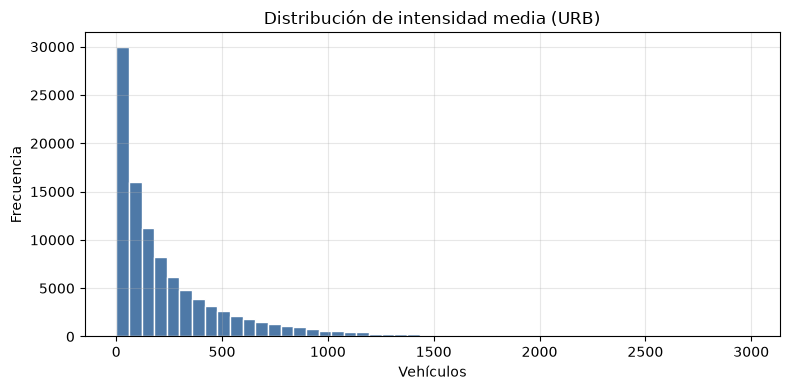

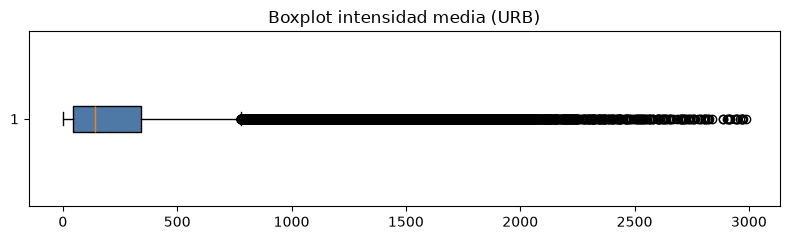

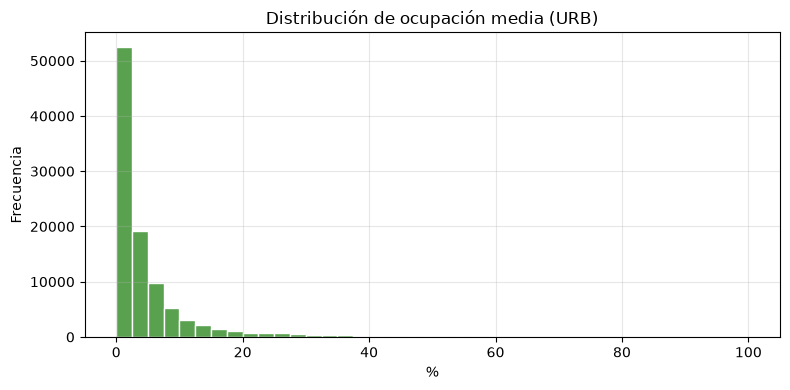

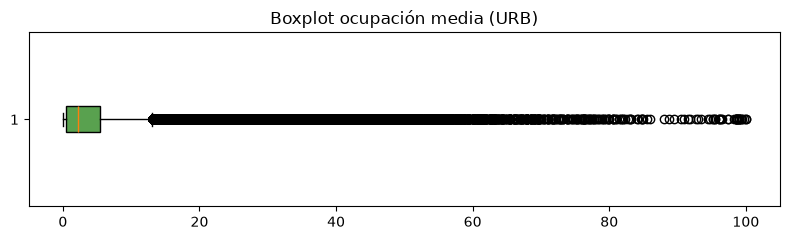

Este tipo de sensor no registra velocidad.
ANÁLISIS M30
Registros: 2,595,362
Sensores: 313


statistic,intensidad_media,ocupacion_media,velocidad_media
str,f64,f64,f64
"""count""",2.595362e6,2.595362e6,2.595362e6
"""null_count""",0.0,0.0,0.0
"""mean""",1194.768451,5.566194,63.528722
"""std""",1274.52447,7.608905,25.611738
"""min""",0.0,0.0,0.0
"""25%""",216.75,0.75,53.0
"""50%""",733.25,3.5,70.25
"""75%""",1788.0,7.5,81.75
"""max""",7666.25,100.0,246.0


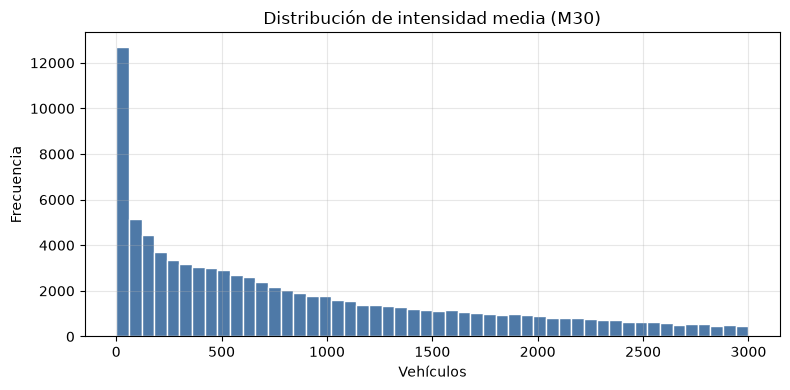

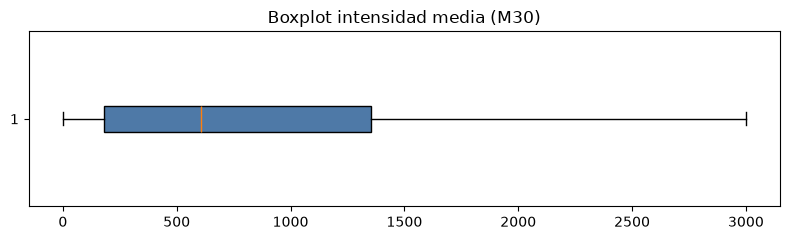

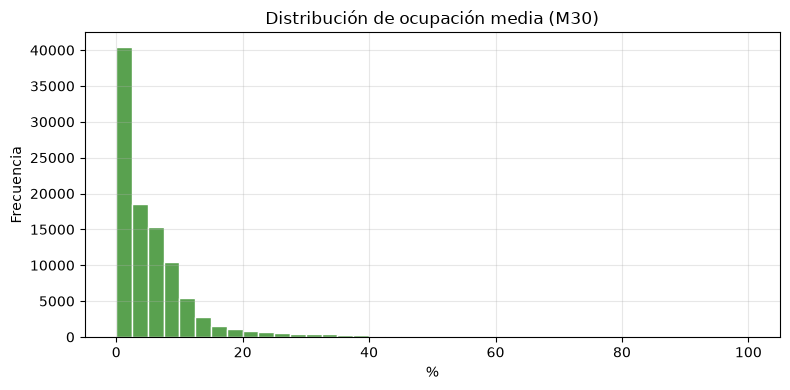

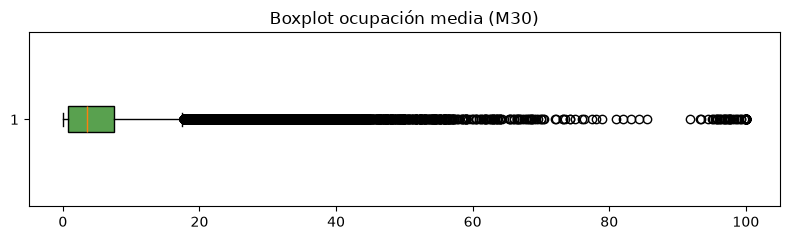

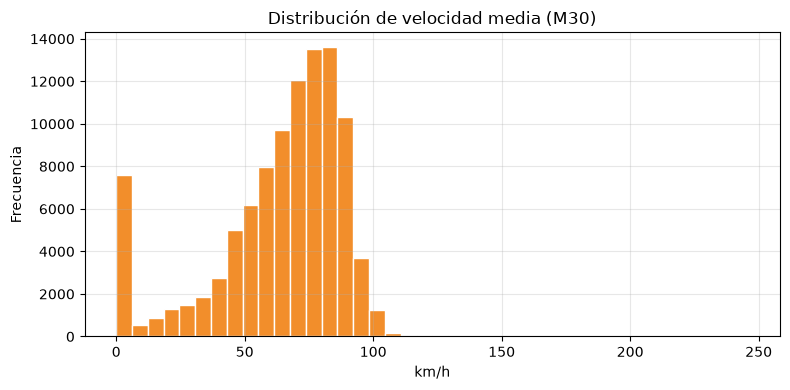

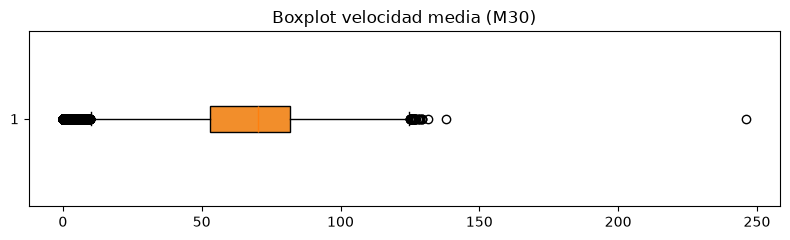

ANÁLISIS other
Registros: 986,611
Sensores: 147


statistic,intensidad_media,ocupacion_media,velocidad_media
str,f64,f64,f64
"""count""",986611.0,986611.0,986611.0
"""null_count""",0.0,0.0,0.0
"""mean""",863.694201,7.887604,43.03545
"""std""",1166.912816,19.524076,28.449479
"""min""",0.0,0.0,0.0
"""25%""",18.0,0.0,11.75
"""50%""",354.0,2.25,53.25
"""75%""",1220.0,6.25,64.75
"""max""",8415.0,100.0,159.75


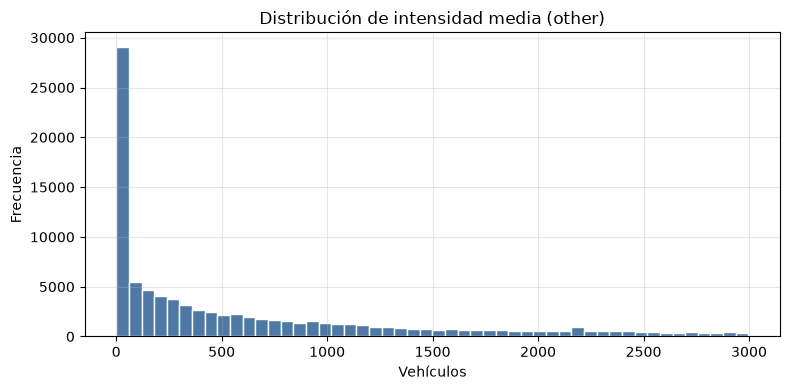

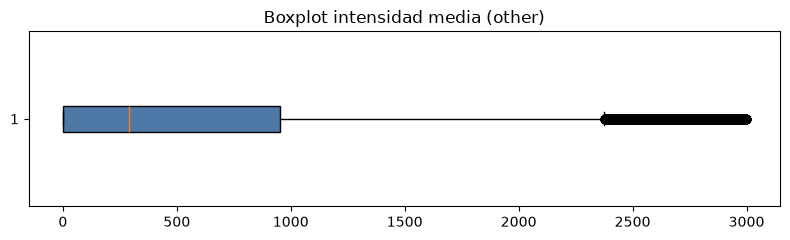

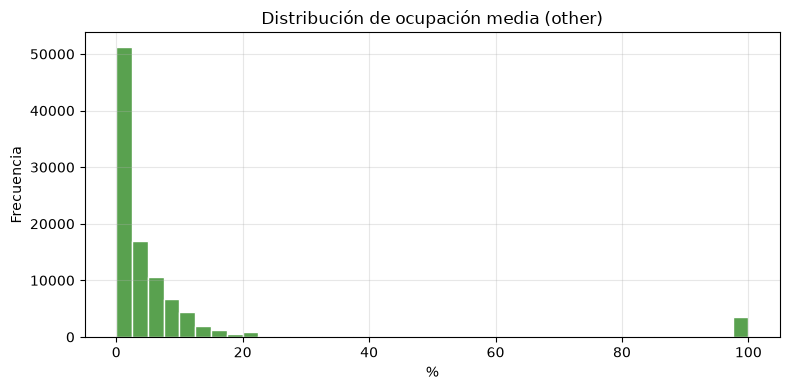

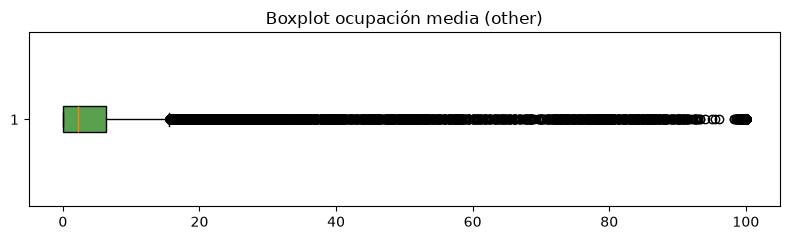

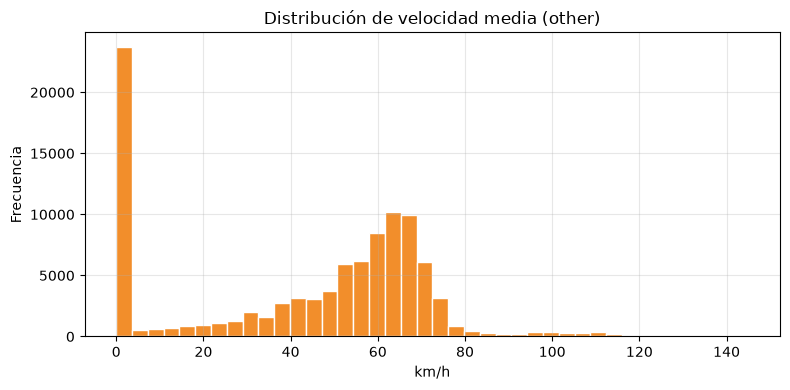

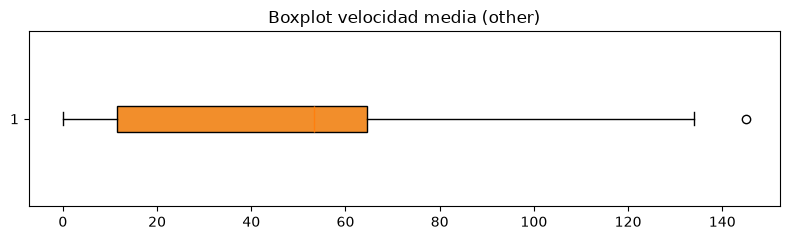

In [15]:
for tipo in ["URB","M30","other"]:

    eda_tipo(df,tipo)

Sensores URB

Los sensores URB representan la mayor parte del conjunto de datos (36,9 millones de registros y 4.473 sensores). La intensidad media presenta una distribución claramente asimétrica a la derecha: la mayoría de las observaciones se concentran en valores bajos, mientras que existe un reducido número de registros con intensidades muy elevadas. El boxplot confirma la presencia de numerosos valores atípicos.

La ocupación media muestra un comportamiento similar, con una elevada concentración de registros en ocupaciones bajas y una cola hacia valores altos, alcanzando el 100 %. También se observan numerosos valores extremos.

En este tipo de sensores no se registran mediciones de velocidad, por lo que esta variable no puede analizarse para los sensores URB.

Sensores M30

Los sensores M30 contienen 2,6 millones de registros distribuidos en 313 sensores. La intensidad media presenta una distribución menos concentrada que en los sensores URB, aunque continúa siendo asimétrica hacia la derecha. La mediana (733 vehículos) es considerablemente inferior a la media (1.195 vehículos), lo que indica la influencia de valores elevados.

La ocupación mantiene un comportamiento similar al observado en los sensores URB, con predominio de valores bajos y presencia de valores atípicos.

La velocidad media muestra una distribución característica, con un gran número de registros entre 50 y 80 km/h, coherente con el tipo de vía. También aparecen algunos valores extremos tanto por debajo como por encima de este intervalo.

Sensores other

Los sensores clasificados como other, correspondientes a vías C30, reúnen cerca de un millón de registros procedentes de 147 sensores. La intensidad media presenta una distribución claramente asimétrica hacia la derecha, con predominio de intensidades bajas y una cola de valores elevados acompañada de numerosos valores atípicos.

La ocupación media también se concentra en porcentajes reducidos, aunque existen registros con ocupaciones próximas al 100 %, lo que explica la presencia de outliers en el boxplot.

La velocidad media muestra una mayor dispersión que en los sensores M30. La mayor parte de los registros se sitúan en velocidades moderadas, aunque aparecen algunos valores extremos que amplían el rango observado.

In [12]:
df["porcentaje_calidad"].describe()

statistic,value
str,f64
"""count""",4.0521392e7
"""null_count""",0.0
"""mean""",99.517551
"""std""",6.845825
"""min""",0.0
"""25%""",100.0
"""50%""",100.0
"""75%""",100.0
"""max""",100.0


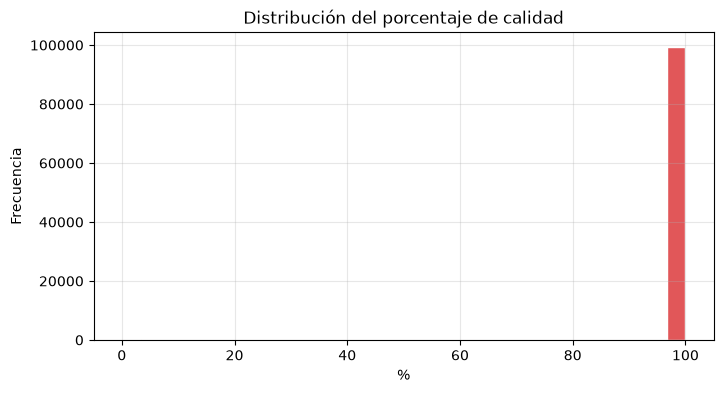

In [13]:
plt.figure(figsize=(8,4))

df.sample(
    100000,
    seed=42
)["porcentaje_calidad"].to_pandas().hist(
    bins=30,
    color="#E15759",
    edgecolor="white"
)

plt.title("Distribución del porcentaje de calidad")

plt.xlabel("%")

plt.ylabel("Frecuencia")

plt.grid(alpha=.3)

plt.show()

El porcentaje de calidad de las mediciones es muy elevado. La media alcanza el 99,52 % y al menos el 75 % de los registros presentan una calidad del 100 %, lo que indica que el conjunto de datos posee un alto nivel de fiabilidad. Los registros con menor calidad son escasos y representan una proporción muy reducida del total.

**Conclusión**: El conjunto de datos presenta una buena calidad, sin problemas relevantes de nulos o duplicados tras el preprocesado. Las variables de tráfico muestran distribuciones asimétricas y diferencias claras entre los tipos de sensores, lo que justifica analizarlos por separado en las siguientes fases del proyecto.